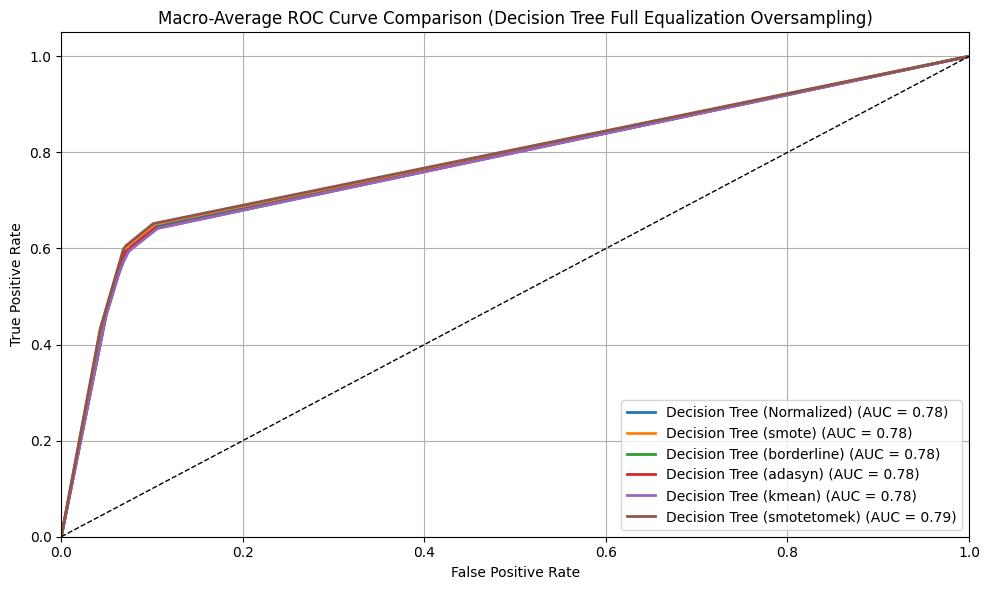

                        Model  Macro AUC
0  Decision Tree (Normalized)   0.781195
1       Decision Tree (smote)   0.784032
2  Decision Tree (borderline)   0.778759
3      Decision Tree (adasyn)   0.778684
4       Decision Tree (kmean)   0.778171
5  Decision Tree (smotetomek)   0.785294


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc
#All sampling
models = {
    'Decision Tree (Normalized)': '/content/drive/MyDrive/Senior_Project/Model/DT/roc/roc_data_DT.csv',
    'Decision Tree (smote)': '/content/drive/MyDrive/Senior_Project/Model/DT/roc/roc_data_DTAllsmo.csv',
    'Decision Tree (borderline)': '/content/drive/MyDrive/Senior_Project/Model/DT/roc/roc_data_DTAllbdl.csv',
    'Decision Tree (adasyn)': '/content/drive/MyDrive/Senior_Project/Model/DT/roc/roc_data_DTAllads.csv',
    'Decision Tree (kmean)': '/content/drive/MyDrive/Senior_Project/Model/DT/roc/roc_data_DTAllkmean.csv',
    'Decision Tree (smotetomek)': '/content/drive/MyDrive/Senior_Project/Model/DT/roc/roc_data_DTAllsmotomek.csv'

}

plt.figure(figsize=(10, 6))
auc_summary = []

for model_name, file_path in models.items():
    df = pd.read_csv(file_path)
    cols = [c.lower() for c in df.columns]

    # --- ถ้ามี column class → ใช้ macro เท่านั้น
    if "class" in cols:
        df_macro = df[df[df.columns[cols.index("class")]] == "macro"]
        fpr = df_macro[df.columns[cols.index("fpr")]].values
        tpr = df_macro[df.columns[cols.index("tpr")]].values
    else:
        fpr = df[df.columns[cols.index("fpr")]].values
        tpr = df[df.columns[cols.index("tpr")]].values

    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {auc_score:.2f})')
    auc_summary.append([model_name, auc_score])

# baseline line
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Average ROC Curve Comparison (Decision Tree Full Equalization Oversampling)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("DTall_ROC.png")
plt.show()

# --- export สรุป AUC เป็นไฟล์ ---
auc_df = pd.DataFrame(auc_summary, columns=["Model", "Macro AUC"])
auc_df.to_csv("DTall_ROC.csv", index=False)
print(auc_df)


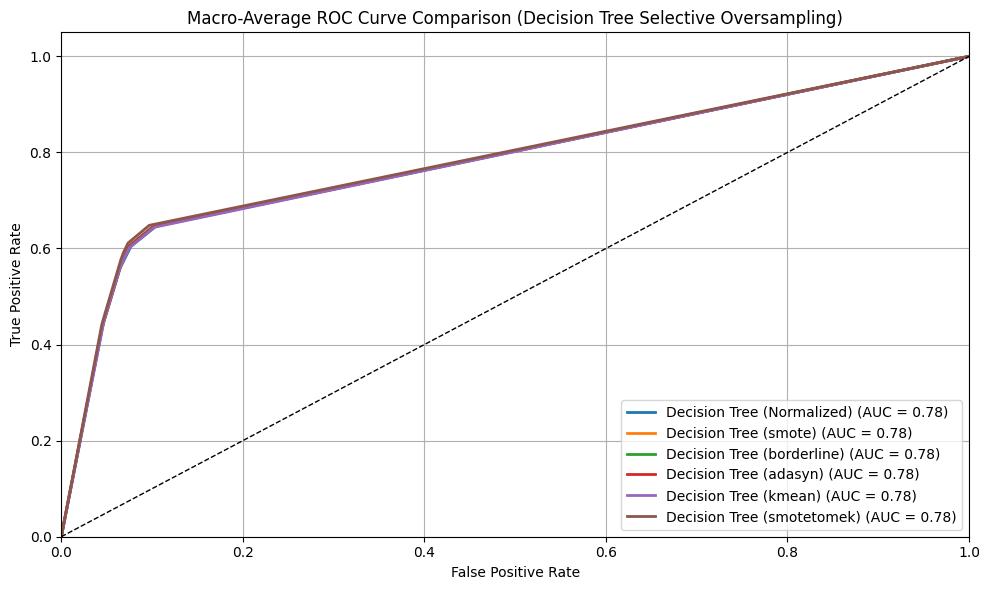

                        Model  Macro AUC
0  Decision Tree (Normalized)   0.781195
1       Decision Tree (smote)   0.781859
2  Decision Tree (borderline)   0.781601
3      Decision Tree (adasyn)   0.781221
4       Decision Tree (kmean)   0.780466
5  Decision Tree (smotetomek)   0.784234


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc
#All sampling
models = {
    'Decision Tree (Normalized)': '/content/drive/MyDrive/Senior_Project/Model/DT/roc/roc_data_DT.csv',
    'Decision Tree (smote)': '/content/drive/MyDrive/Senior_Project/Model/DT/roc/roc_data_DTSomesmo.csv',
    'Decision Tree (borderline)': '/content/drive/MyDrive/Senior_Project/Model/DT/roc/roc_data_DTSomebdl.csv',
    'Decision Tree (adasyn)': '/content/drive/MyDrive/Senior_Project/Model/DT/roc/roc_data_DTSomeads.csv',
    'Decision Tree (kmean)': '/content/drive/MyDrive/Senior_Project/Model/DT/roc/roc_data_DTSomekmean.csv',
    'Decision Tree (smotetomek)': '/content/drive/MyDrive/Senior_Project/Model/DT/roc/roc_data_DTSomesmotomek.csv',

}

plt.figure(figsize=(10, 6))
auc_summary = []

for model_name, file_path in models.items():
    df = pd.read_csv(file_path)
    cols = [c.lower() for c in df.columns]

    # --- ถ้ามี column class → ใช้ macro เท่านั้น
    if "class" in cols:
        df_macro = df[df[df.columns[cols.index("class")]] == "macro"]
        fpr = df_macro[df.columns[cols.index("fpr")]].values
        tpr = df_macro[df.columns[cols.index("tpr")]].values
    else:
        fpr = df[df.columns[cols.index("fpr")]].values
        tpr = df[df.columns[cols.index("tpr")]].values

    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {auc_score:.2f})')
    auc_summary.append([model_name, auc_score])

# baseline line
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Average ROC Curve Comparison (Decision Tree Selective Oversampling)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("DTsome_ROC.png")
plt.show()

# --- export สรุป AUC เป็นไฟล์ ---
auc_df = pd.DataFrame(auc_summary, columns=["Model", "Macro AUC"])
auc_df.to_csv("DTsome_ROC.csv", index=False)
print(auc_df)
